# SmartTeaAI — Exploratory Data Analysis (EDA)

**Project:** An AI-Powered Market Intelligence and Price Forecasting System for the Sri Lankan Tea Industry  
**Student:** A. Malithi Malmi Wimalaweera (st20286196)  
**Module:** CIS6035 Final Dissertation  

**Purpose of this notebook:**  
Explore and understand the unified dataset before training ML models.  
All charts and findings here feed directly into the dissertation's methodology and results chapters.

**Dataset:** `unified_dataset.csv` — 135 usable months (Jan 2015 – Jun 2026), 64 features  
**Target variable:** `price_national_avg` — volume-weighted average tea auction price (Rs/kg)  
**Source:** Colombo Tea Auction via SLTB, with weather, FX, oil, and competitor data merged


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load dataset
df = pd.read_csv("../data/unified_dataset.csv")
df["date"] = pd.to_datetime(df["year_month"])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")
print(f"Split distribution:\n{df['split_set'].value_counts().to_string()}")


Dataset shape: (135, 65)
Date range: 2015-04 to 2026-06
Split distribution:
split_set
train         94
test          21
validation    20


In [16]:
import os
os.makedirs("../data/charts", exist_ok=True)
print("Charts directory ready")


Charts directory ready


## 1. Dataset Overview

First look at the data structure, column types, and missing values.


In [17]:
# Column overview
print(f"Total columns: {len(df.columns)}\n")
print("Columns by category:")

price_cols = [c for c in df.columns if "price" in c.lower() and "lag" not in c and "roll" not in c and "vol" not in c and "spread" not in c]
lag_cols = [c for c in df.columns if "lag" in c or "roll" in c]
prod_cols = [c for c in df.columns if c.startswith("prod_")]
qty_cols = [c for c in df.columns if "quantity" in c]
weather_cols = [c for c in df.columns if "rainfall" in c or "temp" in c]
econ_cols = [c for c in df.columns if "usd_lkr" in c or "fx_" in c or "oil" in c or "mombasa" in c]
time_cols = [c for c in df.columns if c in ["month", "quarter", "is_peak_season"]]

for label, cols in [("Price", price_cols), ("Lag/Rolling", lag_cols), 
                     ("Production", prod_cols), ("Sales Quantity", qty_cols),
                     ("Weather", weather_cols), ("Economic", econ_cols), 
                     ("Time", time_cols)]:
    print(f"  {label}: {len(cols)} — {cols}")


Total columns: 65

Columns by category:
  Price: 5 — ['price_high_rs', 'price_low_rs', 'price_medium_rs', 'oil_price', 'price_national_avg']
  Lag/Rolling: 26 — ['price_high_rs_lag1', 'price_high_rs_lag3', 'price_high_rs_roll3', 'price_low_rs_lag1', 'price_low_rs_lag3', 'price_low_rs_roll3', 'price_medium_rs_lag1', 'price_medium_rs_lag3', 'price_medium_rs_roll3', 'price_national_avg_lag1', 'price_national_avg_lag3', 'price_national_avg_roll3', 'rainfall_mm_high_lag1', 'rainfall_mm_high_lag2', 'rainfall_mm_high_roll3', 'rainfall_mm_medium_lag1', 'rainfall_mm_medium_lag2', 'rainfall_mm_medium_roll3', 'rainfall_mm_low_lag1', 'rainfall_mm_low_lag2', 'rainfall_mm_low_roll3', 'rainfall_mm_lag1', 'rainfall_mm_lag2', 'rainfall_mm_roll3', 'fx_lag1', 'mombasa_lag1']
  Production: 7 — ['prod_high_kg', 'prod_low_kg', 'prod_medium_kg', 'prod_ctc_kg', 'prod_green_tea_kg', 'prod_orthodox_kg', 'prod_total_kg']
  Sales Quantity: 0 — []
  Weather: 20 — ['rainfall_mm_high', 'rainfall_mm_low', 'rainfall_m

In [18]:
# Missing values summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("Columns with missing values:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({100*count/len(df):.1f}%)")
else:
    print("No missing values in the dataset.")

print(f"\nBasic statistics for target variable (price_national_avg):")
print(df["price_national_avg"].describe().round(2))


No missing values in the dataset.

Basic statistics for target variable (price_national_avg):
count     135.00
mean      760.77
std       311.07
min       357.59
25%       533.01
50%       598.51
75%      1074.74
max      1508.08
Name: price_national_avg, dtype: float64


## 2. Tea Auction Price Trend (2015–2026)

The primary target variable over time — this is the most important chart in the dissertation.


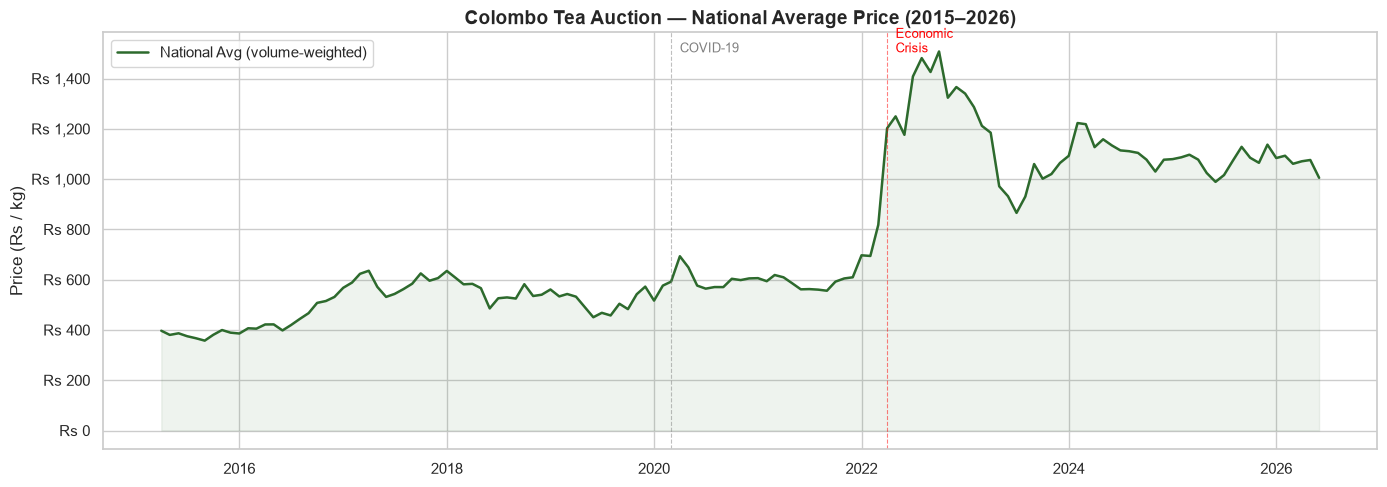

Saved: charts/01_price_trend.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["date"], df["price_national_avg"], color="#2D6A2D", linewidth=1.8, label="National Avg (volume-weighted)")
ax.fill_between(df["date"], df["price_national_avg"], alpha=0.08, color="#2D6A2D")

# Mark key events
ax.axvline(pd.Timestamp("2020-03-01"), color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
ax.text(pd.Timestamp("2020-04-01"), ax.get_ylim()[1]*0.95, "COVID-19", fontsize=9, color="gray")

ax.axvline(pd.Timestamp("2022-04-01"), color="red", linestyle="--", alpha=0.5, linewidth=0.8)
ax.text(pd.Timestamp("2022-05-01"), ax.get_ylim()[1]*0.95, "Economic\nCrisis", fontsize=9, color="red")

ax.set_title("Colombo Tea Auction — National Average Price (2015–2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Price (Rs / kg)")
ax.set_xlabel("")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

plt.tight_layout()
plt.savefig("../data/charts/01_price_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: charts/01_price_trend.png")


## 3. Price by Elevation Category

How do High-Grown, Medium-Grown, and Low-Grown prices compare over time?


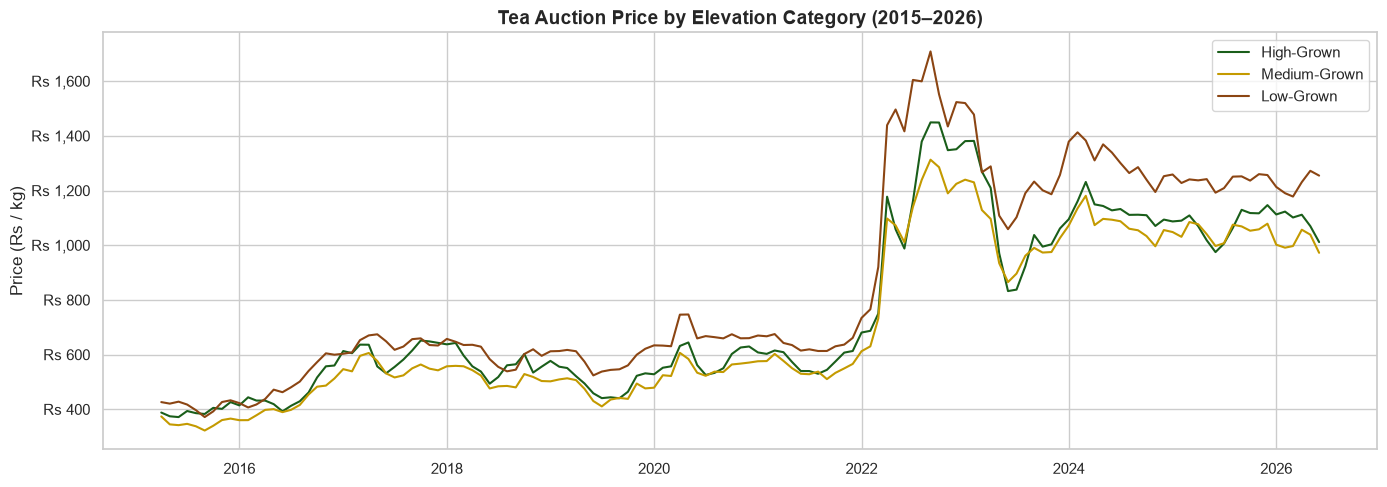

Saved: charts/02_price_by_elevation.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

elev_cols = {
    "price_high_rs": ("High-Grown", "#1a5e1a"),
    "price_medium_rs": ("Medium-Grown", "#C49A00"),
    "price_low_rs": ("Low-Grown", "#8B4513"),
}

for col, (label, color) in elev_cols.items():
    if col in df.columns:
        ax.plot(df["date"], df[col], label=label, color=color, linewidth=1.5)

ax.set_title("Tea Auction Price by Elevation Category (2015–2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Price (Rs / kg)")
ax.legend()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

plt.tight_layout()
plt.savefig("../data/charts/02_price_by_elevation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: charts/02_price_by_elevation.png")


## 4. Seasonal Price Pattern

Average price by calendar month — confirms which months are genuinely high-price months.  
This analysis was used to set `is_peak_season = [1, 2, 3, 4]` in the feature engineering pipeline.


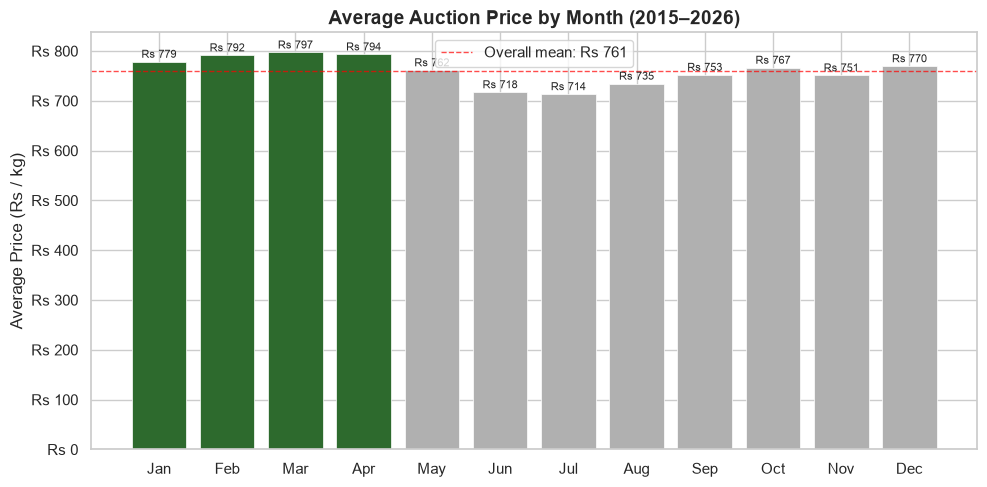

Peak season months (green bars): January, February, March, April
Saved: charts/03_seasonality.png


In [20]:
monthly_avg = df.groupby("month")["price_national_avg"].mean().sort_index()
overall_mean = df["price_national_avg"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2D6A2D" if m in [1, 2, 3, 4] else "#B0B0B0" for m in monthly_avg.index]
bars = ax.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor="white", linewidth=0.5)

ax.axhline(overall_mean, color="red", linestyle="--", linewidth=1, alpha=0.7, label=f"Overall mean: Rs {overall_mean:.0f}")

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Average Auction Price by Month (2015–2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Price (Rs / kg)")
ax.legend()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

# Add value labels
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            f"Rs {val:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../data/charts/03_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Peak season months (green bars): January, February, March, April")
print("Saved: charts/03_seasonality.png")


## 5. Feature Correlation with Target

Which features are most strongly correlated with `price_national_avg`?  
This empirically validates (or challenges) the feature selection from the literature review.


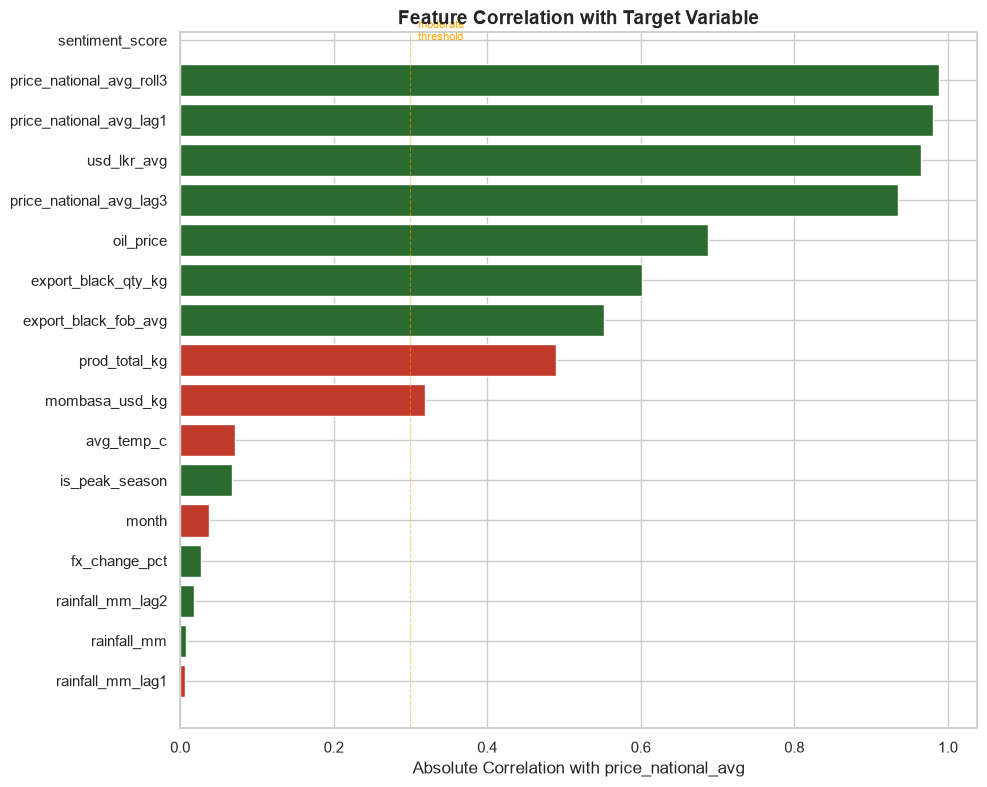


Correlation with price_national_avg (sorted by absolute value):
  - sentiment_score: nan
  + price_national_avg_roll3: 0.989
  + price_national_avg_lag1: 0.981
  + usd_lkr_avg: 0.965
  + price_national_avg_lag3: 0.936
  + oil_price: 0.688
  + export_black_qty_kg: 0.601
  + export_black_fob_avg: 0.552
  - prod_total_kg: -0.490
  - mombasa_usd_kg: -0.319
  - avg_temp_c: -0.071
  + is_peak_season: 0.068
  - month: -0.038
  + fx_change_pct: 0.027
  + rainfall_mm_lag2: 0.019
  + rainfall_mm: 0.008
  - rainfall_mm_lag1: -0.007


In [21]:
# Select only the core features we plan to use for training
core_features = [
    "price_national_avg_lag1", "price_national_avg_lag3", "price_national_avg_roll3",
    "rainfall_mm", "rainfall_mm_lag1", "rainfall_mm_lag2",
    "avg_temp_c",
    "usd_lkr_avg", "fx_change_pct",
    "oil_price",
    "mombasa_usd_kg",
    "export_black_qty_kg", "export_black_fob_avg",
    "prod_total_kg",
    "month", "is_peak_season",
    "sentiment_score",
]

# Filter to columns that actually exist in the dataset
available = [c for c in core_features if c in df.columns]
missing_features = [c for c in core_features if c not in df.columns]
if missing_features:
    print(f"Note: these features not found in dataset: {missing_features}")

corr_with_target = df[available + ["price_national_avg"]].corr()["price_national_avg"].drop("price_national_avg")
corr_sorted = corr_with_target.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2D6A2D" if v > 0 else "#C0392B" for v in corr_with_target[corr_sorted.index]]
ax.barh(range(len(corr_sorted)), corr_sorted.values, color=colors, edgecolor="white")
ax.set_yticks(range(len(corr_sorted)))
ax.set_yticklabels(corr_sorted.index)
ax.set_xlabel("Absolute Correlation with price_national_avg")
ax.set_title("Feature Correlation with Target Variable", fontsize=14, fontweight="bold")
ax.axvline(0.3, color="orange", linestyle="--", alpha=0.5, linewidth=0.8)
ax.text(0.31, len(corr_sorted)-1, "moderate\nthreshold", fontsize=8, color="orange")

plt.tight_layout()
plt.savefig("../data/charts/04_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelation with price_national_avg (sorted by absolute value):")
for feat in corr_sorted.index[::-1]:
    val = corr_with_target[feat]
    direction = "+" if val > 0 else "-"
    print(f"  {direction} {feat}: {val:.3f}")


## 6. Rainfall vs Price Relationship

Ariyaratne et al. (2024) confirmed rainfall as the strongest exogenous factor.  
Does our data show the same pattern? Note: we expect lagged rainfall to be more predictive than same-month rainfall.


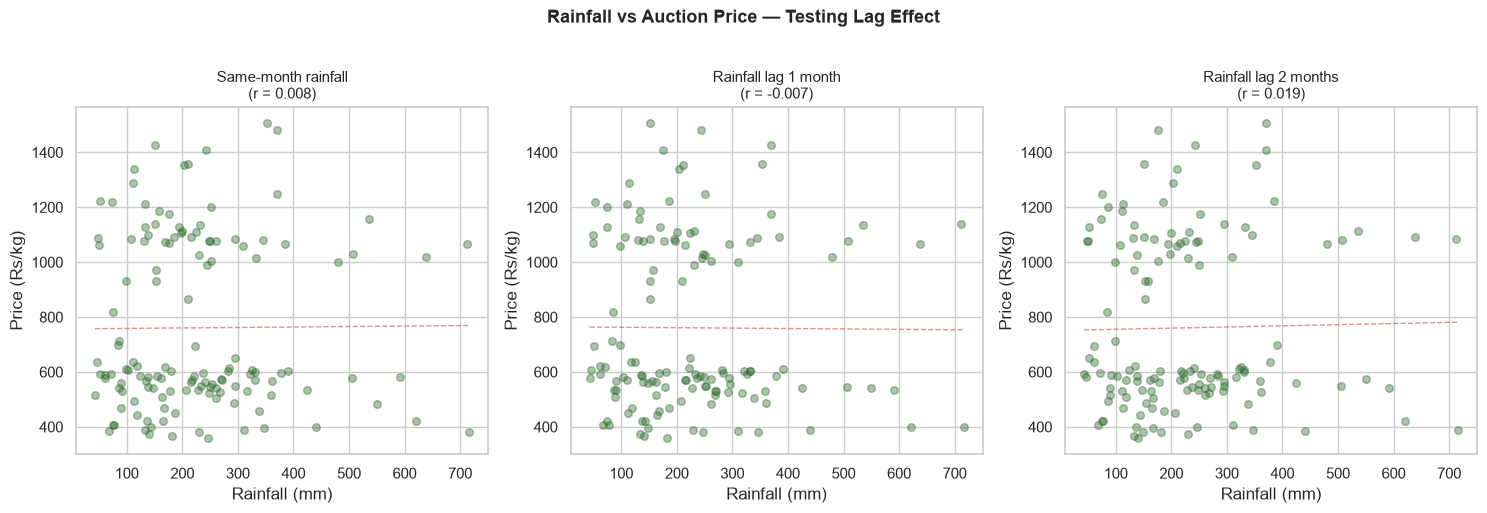

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rain_features = [
    ("rainfall_mm", "Same-month rainfall"),
    ("rainfall_mm_lag1", "Rainfall lag 1 month"),
    ("rainfall_mm_lag2", "Rainfall lag 2 months"),
]

for ax, (col, title) in zip(axes, rain_features):
    if col in df.columns:
        ax.scatter(df[col], df["price_national_avg"], alpha=0.4, color="#2D6A2D", s=30)
        
        # Add trend line
        mask = df[col].notna() & df["price_national_avg"].notna()
        if mask.sum() > 2:
            z = np.polyfit(df.loc[mask, col], df.loc[mask, "price_national_avg"], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df[col].min(), df[col].max(), 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=1)
        
        corr = df[col].corr(df["price_national_avg"])
        ax.set_title(f"{title}\n(r = {corr:.3f})", fontsize=11)
        ax.set_xlabel("Rainfall (mm)")
        ax.set_ylabel("Price (Rs/kg)")

plt.suptitle("Rainfall vs Auction Price — Testing Lag Effect", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/charts/05_rainfall_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. USD/LKR Exchange Rate vs Price

~90% of Ceylon Tea is exported. A weaker rupee makes tea cheaper for foreign buyers.  
Ariyaratne et al. (2024) found that including USD/LKR worsened SARIMAX models — does our data support this concern?


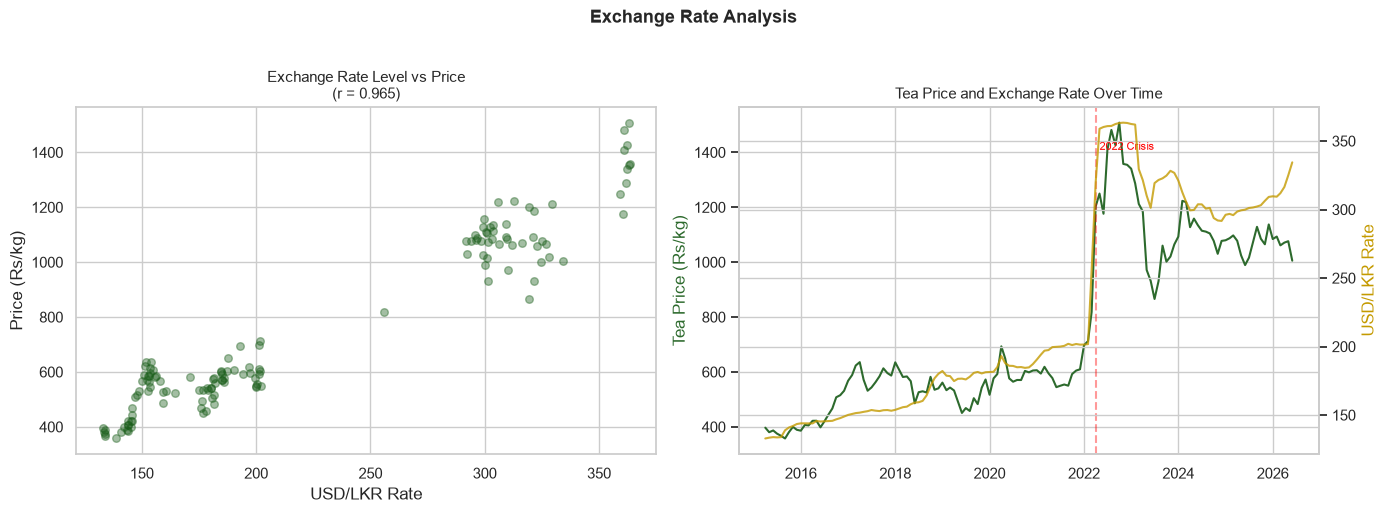

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: FX level vs price
ax1 = axes[0]
ax1.scatter(df["usd_lkr_avg"], df["price_national_avg"], alpha=0.4, color="#1a5e1a", s=30)
corr_level = df["usd_lkr_avg"].corr(df["price_national_avg"])
ax1.set_title(f"Exchange Rate Level vs Price\n(r = {corr_level:.3f})", fontsize=11)
ax1.set_xlabel("USD/LKR Rate")
ax1.set_ylabel("Price (Rs/kg)")

# Plot 2: FX and Price on same timeline (dual axis)
ax2 = axes[1]
ax2.plot(df["date"], df["price_national_avg"], color="#2D6A2D", label="Tea Price", linewidth=1.5)
ax2.set_ylabel("Tea Price (Rs/kg)", color="#2D6A2D")

ax2b = ax2.twinx()
ax2b.plot(df["date"], df["usd_lkr_avg"], color="#C49A00", label="USD/LKR", linewidth=1.5, alpha=0.8)
ax2b.set_ylabel("USD/LKR Rate", color="#C49A00")

ax2.set_title("Tea Price and Exchange Rate Over Time", fontsize=11)
ax2.axvline(pd.Timestamp("2022-04-01"), color="red", linestyle="--", alpha=0.4)
ax2.text(pd.Timestamp("2022-05-01"), ax2.get_ylim()[1]*0.9, "2022 Crisis", fontsize=8, color="red")

plt.suptitle("Exchange Rate Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/charts/06_fx_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Production Volume vs Price

Basic supply-demand: more tea produced should put downward pressure on prices.


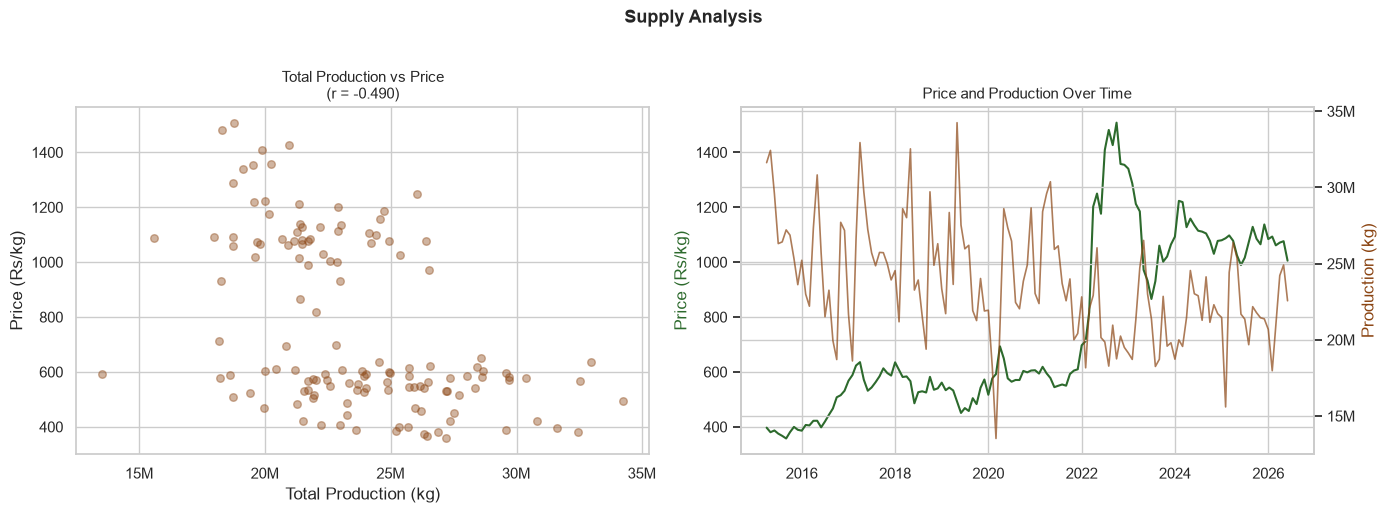

In [24]:
if "prod_total_kg" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter
    ax1 = axes[0]
    ax1.scatter(df["prod_total_kg"], df["price_national_avg"], alpha=0.4, color="#8B4513", s=30)
    corr_prod = df["prod_total_kg"].corr(df["price_national_avg"])
    ax1.set_title(f"Total Production vs Price\n(r = {corr_prod:.3f})", fontsize=11)
    ax1.set_xlabel("Total Production (kg)")
    ax1.set_ylabel("Price (Rs/kg)")
    ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    
    # Timeline
    ax2 = axes[1]
    ax2.plot(df["date"], df["price_national_avg"], color="#2D6A2D", label="Price", linewidth=1.5)
    ax2.set_ylabel("Price (Rs/kg)", color="#2D6A2D")
    ax2b = ax2.twinx()
    ax2b.plot(df["date"], df["prod_total_kg"], color="#8B4513", label="Production", linewidth=1.2, alpha=0.7)
    ax2b.set_ylabel("Production (kg)", color="#8B4513")
    ax2b.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    ax2.set_title("Price and Production Over Time", fontsize=11)
    
    plt.suptitle("Supply Analysis", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("../data/charts/07_supply_vs_price.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("prod_total_kg not found — check preprocess_features.py")


## 9. Mombasa Competitor Tea Price

East African tea competes directly with Ceylon Tea in key export markets (Russia, Iraq, Turkey).


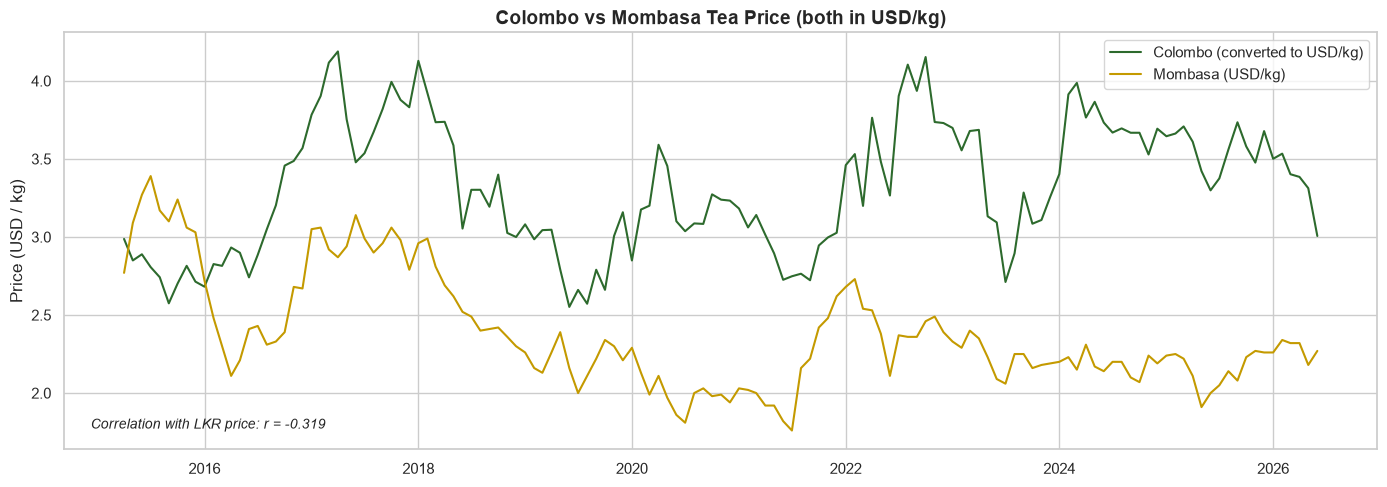

In [25]:
if "mombasa_usd_kg" in df.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(df["date"], df["price_national_avg"] / df["usd_lkr_avg"], 
            color="#2D6A2D", label="Colombo (converted to USD/kg)", linewidth=1.5)
    ax.plot(df["date"], df["mombasa_usd_kg"], 
            color="#C49A00", label="Mombasa (USD/kg)", linewidth=1.5)
    
    ax.set_title("Colombo vs Mombasa Tea Price (both in USD/kg)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Price (USD / kg)")
    ax.legend()
    
    corr_m = df["mombasa_usd_kg"].corr(df["price_national_avg"])
    ax.text(0.02, 0.05, f"Correlation with LKR price: r = {corr_m:.3f}", 
            transform=ax.transAxes, fontsize=10, style="italic")
    
    plt.tight_layout()
    plt.savefig("../data/charts/08_competitor_price.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("mombasa_usd_kg not found in dataset")


## 10. Train / Validation / Test Split

Visual confirmation that the split is chronological — no future data leaking into training.


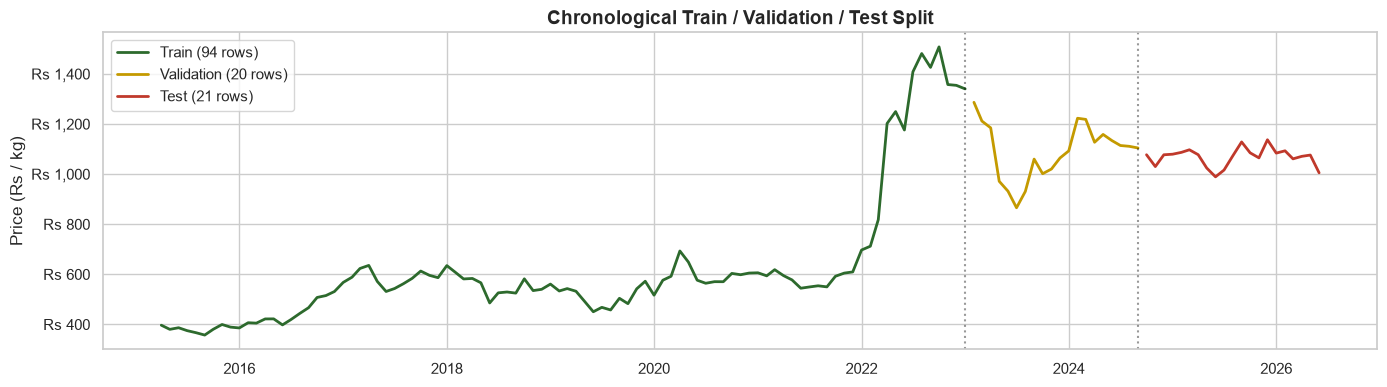

In [26]:
fig, ax = plt.subplots(figsize=(14, 4))

colors_map = {"train": "#2D6A2D", "validation": "#C49A00", "test": "#C0392B"}
labels_map = {"train": "Train (94 rows)", "validation": "Validation (20 rows)", "test": "Test (21 rows)"}

for split_name in ["train", "validation", "test"]:
    mask = df["split_set"] == split_name
    subset = df[mask]
    ax.plot(subset["date"], subset["price_national_avg"], 
            color=colors_map[split_name], linewidth=2, label=labels_map[split_name])

ax.set_title("Chronological Train / Validation / Test Split", fontsize=14, fontweight="bold")
ax.set_ylabel("Price (Rs / kg)")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

# Add split boundary lines
train_end = df[df["split_set"] == "train"]["date"].max()
val_end = df[df["split_set"] == "validation"]["date"].max()
ax.axvline(train_end, color="black", linestyle=":", alpha=0.4)
ax.axvline(val_end, color="black", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("../data/charts/09_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Key EDA Findings

**Complete this section after running all cells above — summarise what the charts show.**

Based on the analysis above:

1. **Price trend:** [Describe the overall trend — stable period, COVID impact, 2022 crisis, recovery]

2. **Elevation differences:** [Which elevation has the highest prices? Is the gap consistent?]

3. **Seasonality:** Peak price months are January through April. `is_peak_season` feature confirmed correct.

4. **Rainfall effect:** [Is lagged rainfall more correlated than same-month? What direction?]

5. **Exchange rate:** [Does FX correlate positively or negatively with tea price? Does the 2022 crisis show a visible relationship?]

6. **Supply effect:** [Does higher production correlate with lower prices as expected?]

7. **Competitor price:** [Does Mombasa price move with or against Colombo?]

8. **Feature selection implications:** [Which features show strong correlation? Which are surprisingly weak?]

*Fill in each finding after reviewing the charts — these go directly into your dissertation Chapter 4/5.*
